In [37]:
from __future__ import annotations

from typing import Annotated, TypedDict,List , operator , Literal

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_groq import ChatGroq

from langchain_core.messages import HumanMessage , AIMessage, SystemMessage

from pydantic import BaseModel, Field
import os 
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [ ]:
# pydentic model
class Task(BaseModel):
    id:int
    title:str
    brief: str = Field(...,description='what to cover')
    goal: str = Field(
        ...,
        description="One sentence describing what the reader should be able to do/understand after this section.",
    )
    bullets: List[str] = Field(
        ...,
        min_length=3,
        max_length=5,
        description="3–5 concrete, non-overlapping subpoints to cover in this section.",
    )
    target_words: int = Field(
        ...,
        description="Target word count for this section (120–450).",
    )
    section_type: Literal[
        "intro", "core", "examples", "checklist", "common_mistakes", "conclusion"
    ] = Field(
        ...,
        description="Use 'common_mistakes' exactly once in the plan.",
    )

class Plan(BaseModel):
    blog_title:str
    tasks: list[Task]   
    audience: str = Field(..., description="Who this blog is for.") 
    tone: str = Field(..., description="Writing tone (e.g., practical, crisp).")


In [23]:
## create state
class State(TypedDict):
    topic:str
    plan: Plan
    #reducer: reducer the results from workers get concatenated automatically
    Sections: Annotated[List[str],operator.add]
    final:str


In [5]:
# set up llm 
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv('GROQ_API_KEY')
)

In [ ]:
def orchestrator(state:State) -> dict:
    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(content=(
                 "You are a senior technical writer and developer advocate. Your job is to produce a "
                    "highly actionable outline for a technical blog post.\n\n"
                    "Hard requirements:\n"
                    "- Create 5–7 sections (tasks) that fit a technical blog.\n"
                    "- Each section must include:\n"
                    "  1) goal (1 sentence: what the reader can do/understand after the section)\n"
                    "  2) 3–5 bullets that are concrete, specific, and non-overlapping\n"
                    "  3) target word count (120–450)\n"
                    "- Include EXACTLY ONE section with section_type='common_mistakes'.\n\n"
                    "Make it technical (not generic):\n"
                    "- Assume the reader is a developer; use correct terminology.\n"
                    "- Prefer design/engineering structure: problem → intuition → approach → implementation → "
                    "trade-offs → testing/observability → conclusion.\n"
                    "- Bullets must be actionable and testable (e.g., 'Show a minimal code snippet for X', "
                    "'Explain why Y fails under Z condition', 'Add a checklist for production readiness').\n"
                    "- Explicitly include at least ONE of the following somewhere in the plan (as bullets):\n"
                    "  * a minimal working example (MWE) or code sketch\n"
                    "  * edge cases / failure modes\n"
                    "  * performance/cost considerations\n"
                    "  * security/privacy considerations (if relevant)\n"
                    "  * debugging tips / observability (logs, metrics, traces)\n"
                    "- Avoid vague bullets like 'Explain X' or 'Discuss Y'. Every bullet should state what "
                    "to build/compare/measure/verify.\n\n"
                    "Ordering guidance:\n"
                    "- Start with a crisp intro and problem framing.\n"
                    "- Build core concepts before advanced details.\n"
                    "- Include one section for common mistakes and how to avoid them.\n"
                    "- End with a practical summary/checklist and next steps.\n\n"
                    "Output must strictly match the Plan schema."
                
                
                
                )
                          ),
            HumanMessage(content=(f"topic: {state['topic']}"))              
        ]
    )
    return {'plan':plan}

In [19]:
# fan out worker
def fan_out(state:State):
    return [ Send('worker',{'task':task, 'topic':state['topic'], 'plan':state['plan'] })
        for task in state['plan'].tasks]

In [20]:
def worker(payload:dict) -> dict:
    # payload contain what we send
    task = payload['task']
    topic = payload['topic']
    plan = payload['plan']

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content='write clean one markdown section'),
            HumanMessage(content=(
                f"blog : {blog_title}\n" 
                f"topic: {topic}\n"
                f"Section: {task.title}\n"
                f"brief: {task.brief}"
            ))
        ]
    ).content.strip()
    return {'Sections':[section_md]}


In [26]:
from pathlib import Path
def reducer(state:State):
    title = state['plan'].blog_title
    body = '\n\n'.join(state['Sections']).strip()

    final_md = f'# {title} \n\n {body} \n'

    file_name = title.lower().replace('-','_')+'.md'
    output_path = Path(file_name)
    output_path.write_text(final_md,encoding='utf-8')
    return {"final":final_md}


In [27]:
# create graph
graph = StateGraph(State)

graph.add_node('orchestrator',orchestrator)
graph.add_node('worker',worker)
graph.add_node('reducer',reducer)

graph.add_edge(START,'orchestrator')
graph.add_conditional_edges('orchestrator',fan_out,['worker'])
graph.add_edge('worker','reducer')
graph.add_edge('reducer', END)

workflow = graph.compile()

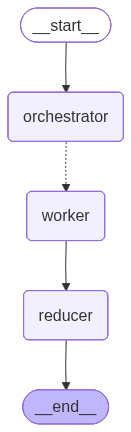

In [28]:
workflow

In [29]:
out = workflow.invoke({'topic':'write a blog on self attention'})

In [35]:
out

{'topic': 'write a blog on self attention',
 'plan': Plan(blog_title='Understanding Self-Attention in Deep Learning', tasks=[Task(id=1, title='Introduction to Self-Attention', brief='Provide a brief overview of self-attention and its importance in deep learning'), Task(id=2, title='How Self-Attention Works', brief='Explain the mechanism behind self-attention, including the query, key, and value vectors'), Task(id=3, title='Types of Self-Attention', brief='Discuss the different types of self-attention, including multi-head attention and scaled dot-product attention'), Task(id=4, title='Applications of Self-Attention', brief='Explore the various applications of self-attention in natural language processing, computer vision, and other fields'), Task(id=5, title='Challenges and Limitations of Self-Attention', brief='Discuss the challenges and limitations of self-attention, including its computational cost and potential for overfitting'), Task(id=6, title='Best Practices for Implementing Se